In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
print(f(5))

60


In [4]:
x_series = np.arange(1,15,2)

In [5]:
x_series

array([ 1,  3,  5,  7,  9, 11, 13])

In [6]:
y_series = f(x_series)

In [7]:
y_series

array([  4,  20,  60, 124, 212, 324, 460])

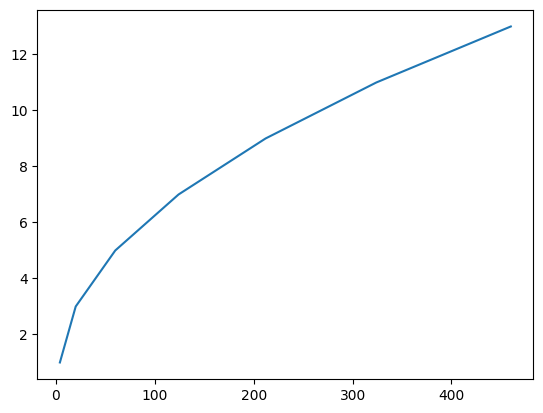

In [8]:
plt.plot(y_series,x_series)
plt.show()

In [11]:
x=3.0
h=0.000000000000001
(f(x+h)-f(x))/h

10.658141036401503

## the reason we += to the grad of the values while performing the backward method and not assign the values is that in case somewhere in our calculations we are re-using the variables then it helps us accumulate the gradient and not replace them.

In [13]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None ## This is done so when we are initially creating the Value Object the backward value is not calculated
        # internal variables used for autograd graph construction
    self._prev = set(_children)
    self._op = _op # the op that produced this node, for graphviz / debugging / etc
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other) ## This is done to ensure we can add even simple integers with our object
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self This is done so that we use 2 * a instead of a * 2 it changes the places and calls mul
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
     ## Defining the intial backpropagation assuming in our given model the last operation is tanh. Assuming tanh = t, then the derivative of it is 1-t2  
   
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad 
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [14]:
from graphviz import Digraph

In [15]:

def trace(root):
    ## Builds out the entire calculation in a graph
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg',graph_attr = {'rankdir':'LR'})
    nodes,edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # for any value in the graph create a rectangular box to indcate a value 
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')


        if n._op:
            dot.node(name=uid+n._op, label = n._op)
            dot.edge(uid+n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

In [16]:
h = 0.00001
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(L)


Value(data=-8.0)


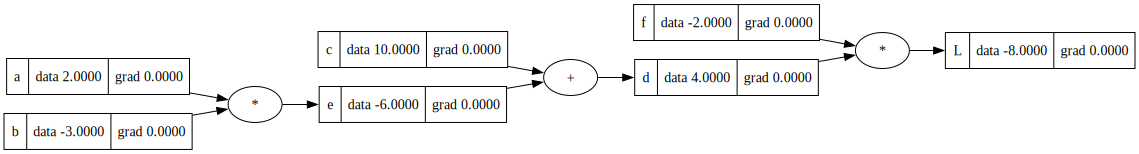

In [17]:
draw_dot(L)

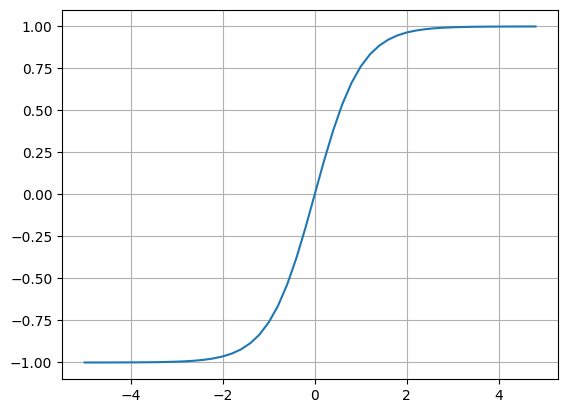

In [18]:
## ACtivation functions
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()
plt.show()

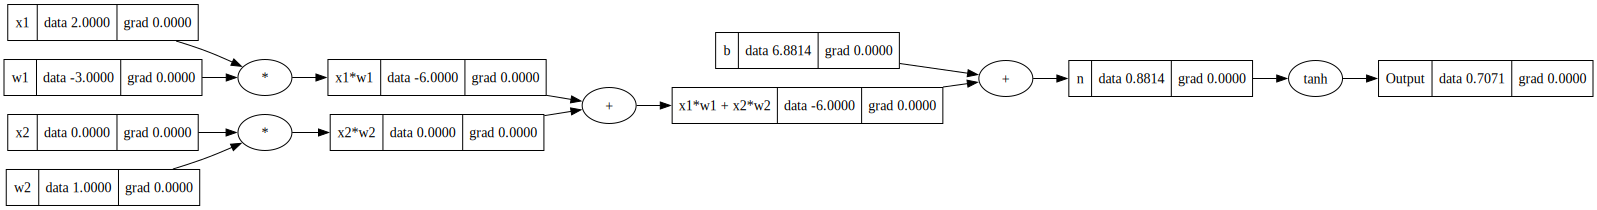

In [19]:
## A simple neuron with two weight
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
o.label="Output"


draw_dot(o)

In [20]:
o.grad=1


In [21]:
##why does the backward method hit the __backward in tanh and not in other def

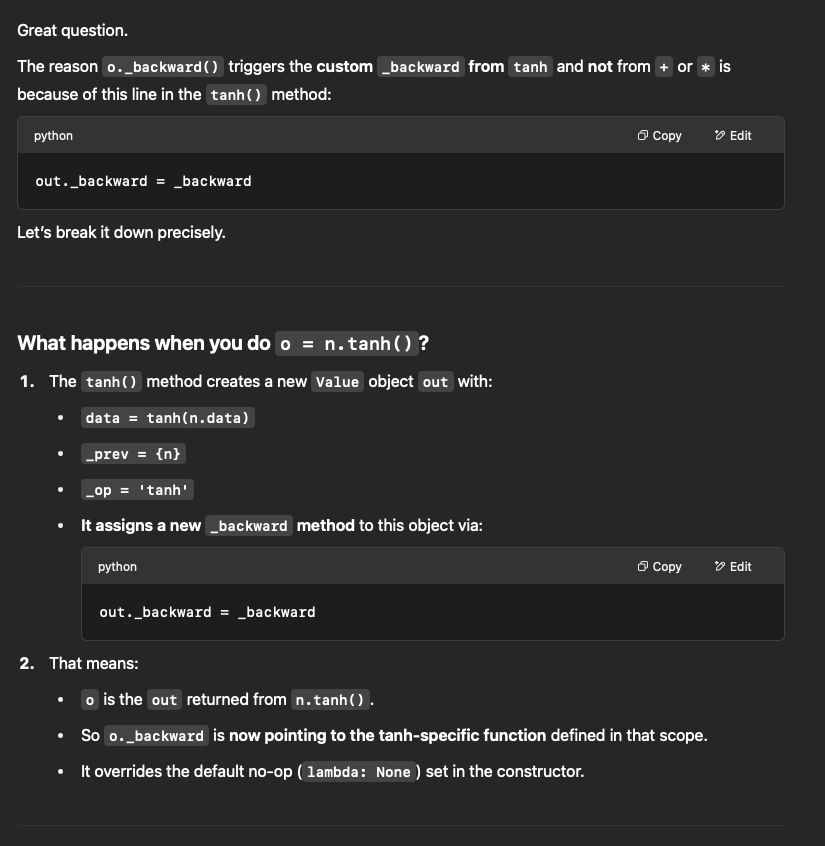

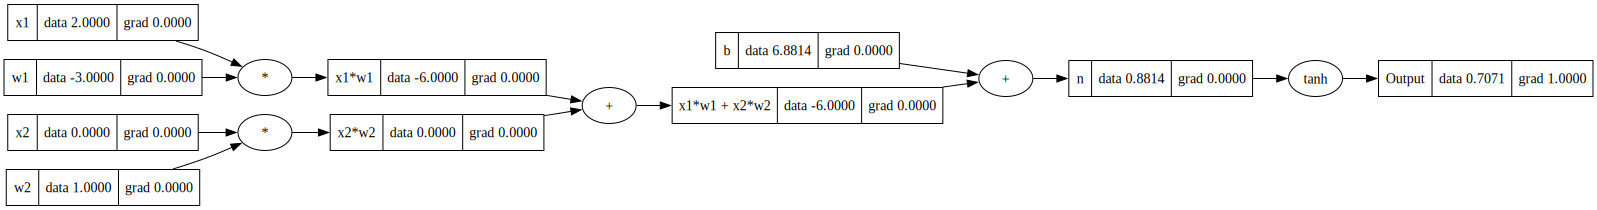

In [22]:
draw_dot(o)

In [23]:
import random

In [129]:
class Neuron:
    def __init__(self,nin): ## Here nin is the number of nodes are in this neuron 
        self.w = [Value(random.uniform(-1,1),label=f'w{i}') for i in range (nin)] ## Setting random weights and biases between -1 and 1 during initialization
        self.b = Value(random.uniform(-1,1),label="b")

    def __call__(self,x): ## when the neuron 
    ## Here essentially we need to multiply each weight with its corresponding input and then sum it up and add with a bias
    ## w@x + b is the maths
    ## zip takes two iterables and makes tuples to loop thorugh then simulatenously 
        # if len(x) != len(self.w):
        #     raise ValueError(f"Expected {len(self.w)} inputs, but got {len(x)}")
        act = sum((wi*xi for wi, xi in zip(self.w, x))) + self.b
        out = act.tanh()
        return out
        
    def parameters(self):
        return self.w + [self.b]

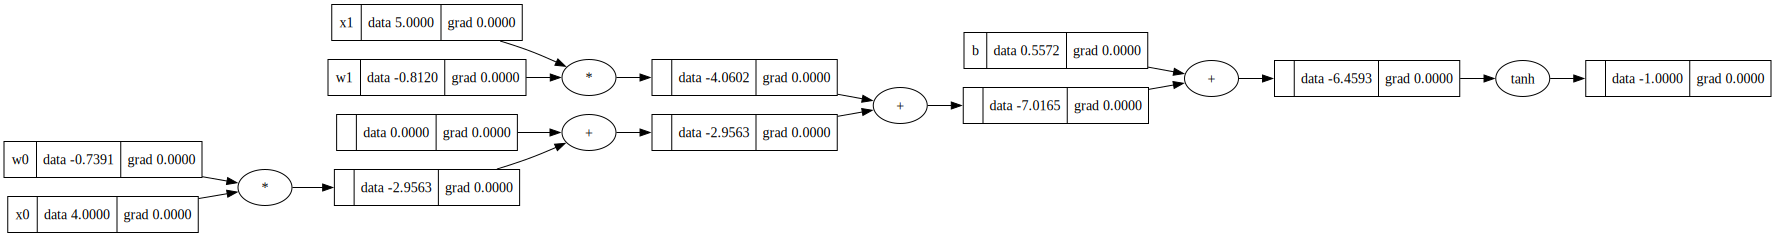

In [92]:
x = [Value(4.0, label='x0'), Value(5.0, label='x1')]
a = Neuron(2)
draw_dot(a(x))


In [130]:
class Layer:
     ## creating as many neurons as the number of outputs from this layer where each nueron is fully connected to the previous layer and hence each neuron has nin inputs

    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]    

In [133]:
class MLP:
    def __init__(self,nin,nouts):
        sz= [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range (len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            out = layer(x)
        return out[0] if len(out) ==1 else out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]    

In [134]:
x=[Value(4.0, label='x0'), Value(5.0, label='x1')]
b=Layer(2,3)
##b =MLP(6,[6,1])
c= b(x)


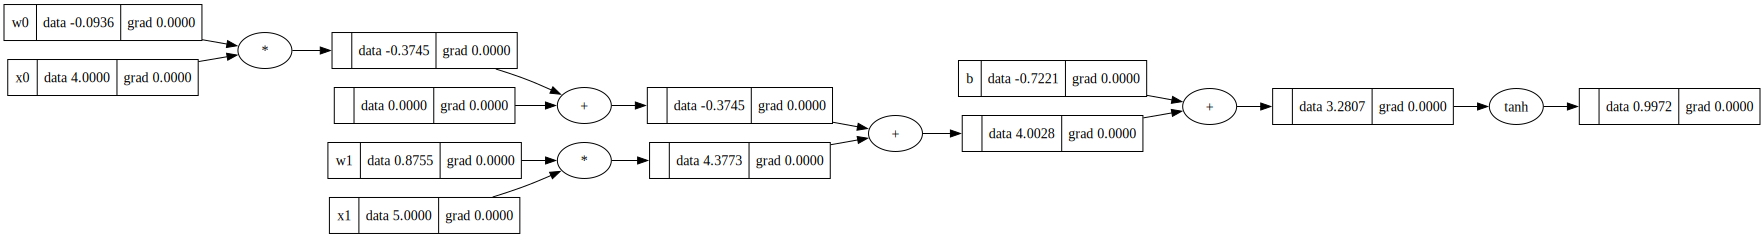

In [107]:
draw_dot(c[0])


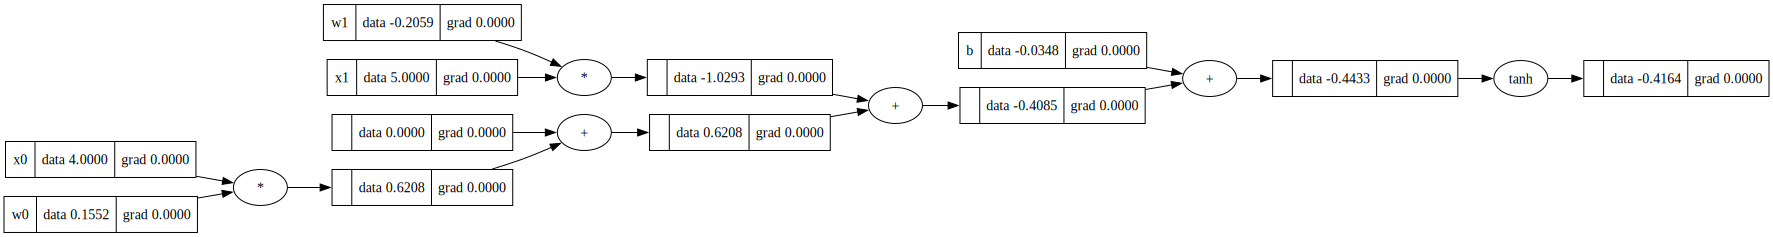

In [108]:
draw_dot(c[1])

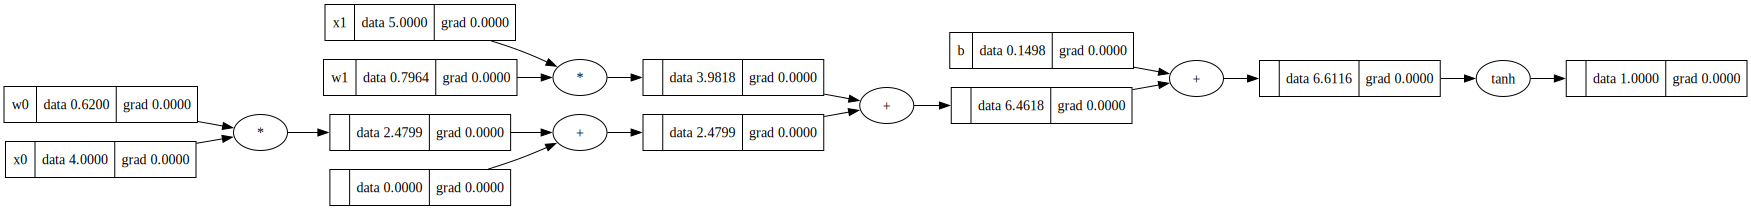

In [109]:
draw_dot(c[2])

In [135]:
i = [3,-5,7]
a = MLP (3,[3,2,3,1])
x=a(i)
#x.backward()

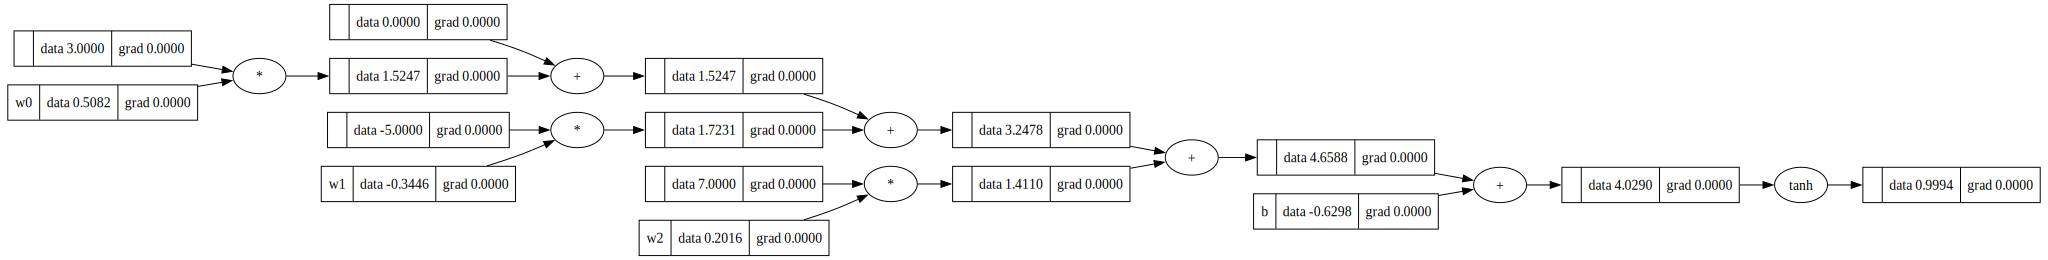

In [136]:
draw_dot(x)

## Creating a small dataset and trying to compute Gradient Descent

In [159]:
model = MLP(3,[3,4,5,1])
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [163]:
ypred =[ model(x) for x in xs]
ypred

[Value(data=0.7613758755644073),
 Value(data=0.3350418241310343),
 Value(data=-0.8725710497317325),
 Value(data=0.5236040448702093)]

In [164]:
loss = sum ((yout-ygt)**2 for ygt, yout in zip(ys,ypred))
loss

Value(data=2.082469388372271)

In [167]:
len(model.parameters())

59

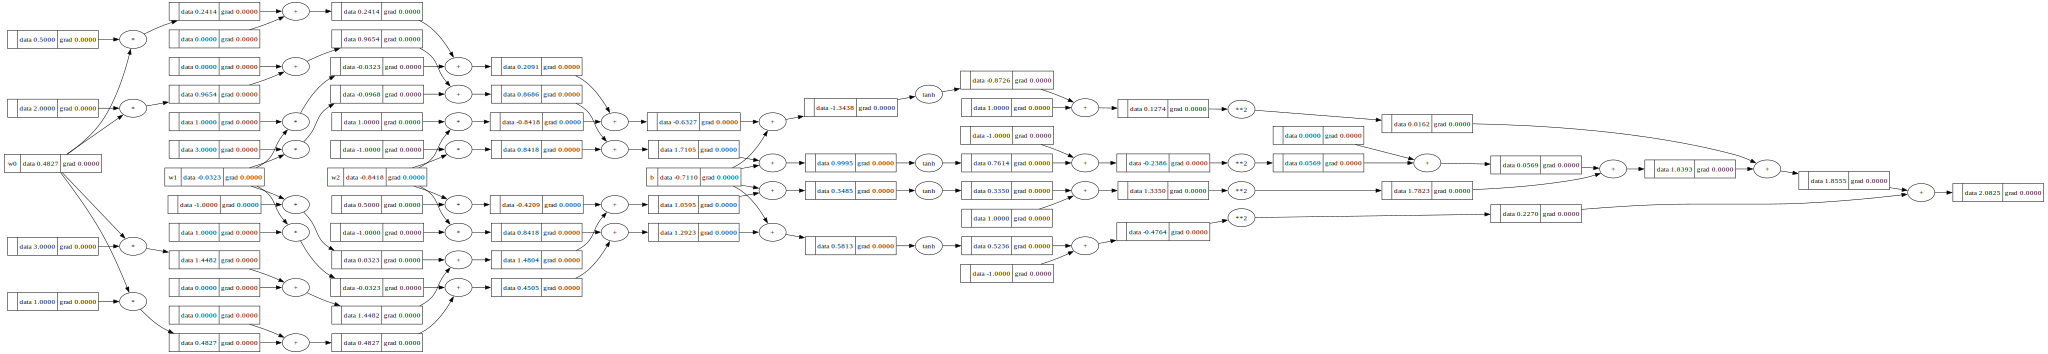

In [168]:
draw_dot(loss)

In [169]:
loss.backward()

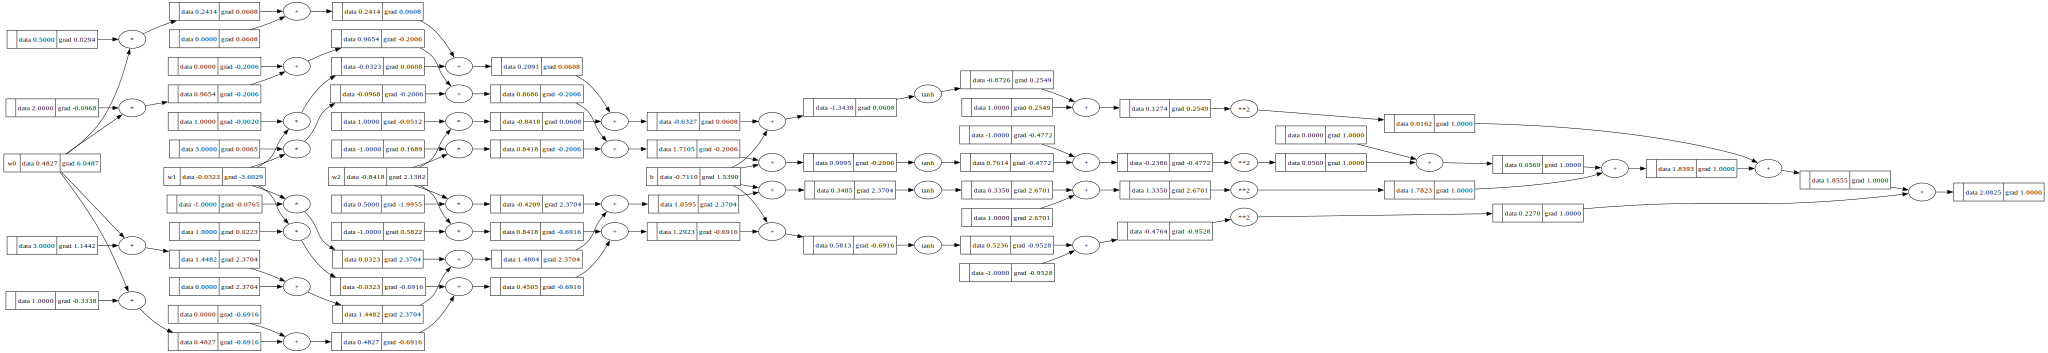

In [170]:
draw_dot(loss)

In [171]:
for k in range(20):
  
  # forward pass
  ypred = [model(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in model.parameters():
    p.grad = 0.0
  loss.backward() 
  
  # update
  for p in model.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 2.082469388372271
1 0.4664184354491131
2 0.07546230962891148
3 0.06290398361925006
4 0.055342184206972164
5 0.0501040648265985
6 0.04614163168943851
7 0.04296435794188213
8 0.04031365766118608
9 0.03804035148676181
10 0.036051843156159474
11 0.0342870247662503
12 0.032703424969128744
13 0.031270208794412876
14 0.029964157938779656
15 0.02876725225467014
16 0.027665152216942032
17 0.026646209731041336
18 0.02570080060590961
19 0.024820859727703246
